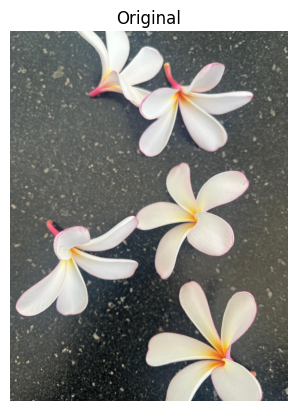

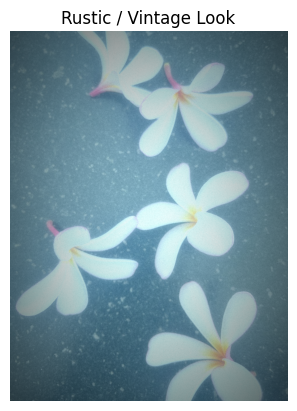

In [78]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv2.imread("flower3.jpeg").astype(np.float32) / 255.0
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# --- 1. Blur ---
blur = cv2.GaussianBlur(img, (0, 0), sigmaX=10, sigmaY=10)

# --- 2. Glow ---
glow = cv2.addWeighted(img, 0.6, blur, 0.4, 0)

# --- 3. Fade contrast ---
low_contrast = glow * 0.8 + 0.2

# --- 4. Warm/Sepia Tint ---
# --- 4. Stronger Yellow/Warm Tint ---
sepia = np.zeros_like(low_contrast)
sepia[:, :, 0] = -0.05   # 🔵 reduce blue
sepia[:, :, 1] = 0.15    # 🟢 boost green
sepia[:, :, 2] = 0.25    # 🔴 boost red

colorized = np.clip(low_contrast + sepia, 0, 1)

# --- 5. Matte Effect (lift blacks) ---
matte = colorized * 0.9 + 0.1

# --- 6. Film Grain (better than harsh noise) ---
noise = np.random.normal(0, 0.03, (img.shape[0], img.shape[1], 1))
noise = np.repeat(noise, 3, axis=2)

grainy = np.clip(matte + noise, 0, 1)

# --- 7. Vignette (dark edges) ---
rows, cols = img.shape[:2]
X = cv2.getGaussianKernel(cols, cols/2)
Y = cv2.getGaussianKernel(rows, rows/2)
vignette = Y @ X.T
vignette = vignette / vignette.max()

vignette = np.dstack([vignette]*3)

final = grainy * vignette

# --- Convert to uint8 ---
output = (final * 255).astype(np.uint8)

# Save
cv2.imwrite("rustic_output.jpg", cv2.cvtColor(output, cv2.COLOR_RGB2BGR))

# Display
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.figure()
plt.imshow(output)
plt.title("Rustic / Vintage Look")
plt.axis("off")

plt.show()